# **Impact Analysis of Workplace Location on Hemoglobin Metrics (ANOVA)**

#### **1. Introduction**

### Project Overview
This study analyzes the effectiveness of rehabilitation programs for industrial plant employees. The **dynamics of hemoglobin levels ($\Delta Hb$)** are utilized as the key biomarker for the recovery process. The project investigates whether specific environmental conditions at different production sites exert a systemic influence on treatment outcomes when standardized medical protocols are applied. **The findings serve as a foundation for assessing cognitive adaptation and developing personalized approaches in adult education and wellness.**

### Research Objective
To statistically verify the presence of significant differences in the **individual gain** of hemoglobin levels among employees from three independent enterprises. The goal is to mathematically justify the homogeneity of the therapeutic effect or to identify the need for differentiation and **individualization** of approaches based on the production factor.

### Tech Stack and Competencies
A specialized Python-based analytical stack was utilized to implement the research cycle:
* **Pandas / NumPy** – Data structuring, cleaning, **calculation of derived metrics (delta)**, and descriptive statistics.
* **SciPy.stats** – Verification of mathematical assumptions: Shapiro-Wilk test for normality and Levene’s test for homogeneity of variance.
* **Statsmodels** – Conducting One-Way Analysis of Variance (ANOVA) and Post-hoc comparisons using the Tukey HSD (Honestly Significant Difference) method.
* **Seaborn / Matplotlib** – Advanced expert visualization (Q-Q plots, **Boxplots with letter-based significance notation**, p-value matrices).

### Analysis Structure
1.  **Statistical Assumption Testing:** Analysis of distributions and equality of variances to justify the selection of parametric methods.
2.  **Descriptive Analysis:** Calculation of central tendencies and variability measures of the **metric gain** for each site.
3.  **Analysis of Variance (ANOVA):** Global hypothesis testing regarding the influence of the "Enterprise" factor on **rehabilitation effectiveness**.
4.  **Post-hoc Analysis (Tukey’s Test):** Localization of significant differences between specific pairs of enterprises and **grouping of objects by effectiveness level**.
5.  **Interpretation and Conclusions:** Synthesis of statistical data and visualizations to formulate the final clinical/operational conclusion.

#### Sample Characteristics and Research Design

**Sample Design:** The study involved **600 employees** (200 from each of the three enterprises). To ensure group homogeneity and minimize the impact of demographic factors on hemoglobin levels, a specific sample was curated:
* **Gender:** Male only.
* **Age:** 20–40 years.
* **Observation Period:** 14 days (inpatient rehabilitation).

**Selection Bias Control:**
The use of a narrow age bracket and a single-gender cohort eliminates natural physiological fluctuations in hemoglobin related to aging or gender differences. This ensures that any identified differences are attributable to external factors (environmental conditions at the plants) and the effectiveness of the rehabilitation, rather than group composition.

**Data Structure:**
Measurements were taken dynamically ("before-after" design). The initial dataset contains 6 key indicators:
* **Hb[N]Bef:** Baseline level upon admission.
* **Hb[N]Aft:** Control level upon discharge (after 14 days).
*(where N represents the enterprise number from 1 to 3)*.


In [1]:
from google.colab import files
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [3]:
df = pd.read_excel('task1.xlsx')

print(f"Dataset size: {df.shape}")
df.head()

Dataset size: (200, 7)


,Unnamed: 0,Hb1Bef,Hb1Aft,Hb2Bef,Hb2Aft,Hb3Bef,Hb3Aft
0,0,136,126,114,121,136,127
1,1,114,138,128,137,136,105
2,2,115,124,131,122,113,134
3,3,109,150,139,127,126,126
4,4,129,117,123,117,127,114


In [4]:
f_stat, p_val = stats.f_oneway(df['Hb1Bef'], df['Hb2Bef'], df['Hb3Bef'])
print(f"Group equality at baseline: p = {p_val:.4f}")

Group equality at baseline: p = 0.0000


**Initial Data Characteristics and Analysis Design**

A primary analysis of the input metrics revealed that the employee groups across the three enterprises exhibited statistically significant differences in hemoglobin levels **prior to** the start of rehabilitation ($p < 0.05$). This indicates the presence of a systematic **baseline bias**, likely caused by differences in working conditions or the specific industrial environments at each site.

Since the groups were not equivalent at the outset, a direct comparison of final outcomes (post-treatment) could lead to erroneous conclusions. To obtain an objective assessment of the medical intervention’s effectiveness, this study focuses primarily on the analysis of **individual gain** in metrics ($\Delta Hb = Hb_{After} - Hb_{Before}$). This approach mitigates the "baseline effect" and allows for an evaluation of the net contribution of rehabilitation at each enterprise.

---

## **2. Preliminary Overview and Visual Data Analysis**

At this stage, an initial inspection of the data is conducted, key measures of central tendency are calculated, and the distribution shape of the studied variable is assessed for each group.

### 2.1. Calculation of Descriptive Statistics

For the initial evaluation, a summary table has been prepared, including means, medians, and dispersion metrics of hemoglobin (Hb) levels for the workers at the three enterprises (total sample size $N=600$).


In [5]:
# 1. Rationale for Metric Selection
# Shifting from absolute values to Delta (gain) analysis,
# as the groups were not equivalent at baseline.
df['Delta1'] = df['Hb1Aft'] - df['Hb1Bef']
df['Delta2'] = df['Hb2Aft'] - df['Hb2Bef']
df['Delta3'] = df['Hb3Aft'] - df['Hb3Bef']

# Reshape data to long format for ANOVA
data_long = pd.melt(df[['Delta1', 'Delta2', 'Delta3']],
                    var_name='Enterprise',
                    value_name='Hb_Delta').dropna()

# Standardize labels
data_long['Enterprise'] = data_long['Enterprise'].str.replace('Delta', 'Enterprise ')

print(f"Total sample size: {len(data_long)} participants")

print("H0: Mean hemoglobin gain (Delta Hb) is identical across all enterprises.")
print("H1: There are statistically significant differences in rehabilitation effectiveness.")

# 4. Calculation of Extended Descriptive Statistics
summary_stats = data_long.groupby('Enterprise')['Hb_Delta'].agg([
    'count',
    'mean',
    'std',
    'min',
    ('Q1', lambda x: x.quantile(0.25)),
    'median',
    ('Q3', lambda x: x.quantile(0.75)),
    'max'
]).T

# Add Interquartile Range (IQR) and Coefficient of Variation (CV)
summary_stats.loc['IQR'] = summary_stats.loc['Q3'] - summary_stats.loc['Q1']
summary_stats.loc['CV (%)'] = (summary_stats.loc['std'] / summary_stats.loc['mean']) * 100

print("Descriptive statistics for Hemoglobin Gain (ΔHb):")
display(summary_stats.round(2))

Total sample size: 600 participants
H0: Mean hemoglobin gain (Delta Hb) is identical across all enterprises.
H1: There are statistically significant differences in rehabilitation effectiveness.
Descriptive statistics for Hemoglobin Gain (ΔHb):


Enterprise,Enterprise 1,Enterprise 2,Enterprise 3
count,200.00,200.00,200.00
mean,8.90,3.21,-0.12
std,14.09,13.74,14.01
min,-24.00,-54.00,-38.00
Q1,-0.25,-5.00,-9.00
median,9.00,3.50,0.00
Q3,17.25,12.00,9.00
max,43.00,41.00,38.00
IQR,17.50,17.00,18.00
CV (%),158.22,428.02,-11206.87


The analysis of hemoglobin gain dynamics ($\Delta Hb$) revealed a pronounced heterogeneity in rehabilitation effectiveness across the study groups:

1.  **Efficiency Leadership:** The strongest recovery results were recorded at **Enterprise 1**. The mean gain reached **8.90 g/L**, which is nearly three times higher than the metrics for Enterprise 2 (3.21 g/L).
2.  **Stagnation of Dynamics:** **Enterprise 3** exhibited a stagnation in metrics, with a mean gain near zero (-0.12 g/L) and a median of 0.00. This indicates that for half of the workers at this site, rehabilitation did not lead to any meaningful change in hemoglobin levels.
3.  **Variability and Stability:** High values for the Coefficient of Variation (CV) and Interquartile Range (IQR ≈ 17–18) across all groups point to a significant spread in individual patient responses to treatment. However, Enterprise 1 demonstrates the most "confident" positive trend, as even its lower quartile (Q1 = -0.25) sits substantially higher than that of Enterprise 3 (Q1 = -9.00).

Descriptive data strongly support the rejection of the null hypothesis $H_0$. The rehabilitation program at Enterprise 1 qualitatively outperforms the results of other sites. To statistically validate this conclusion, an ANOVA test on the gain data ($\Delta Hb$) is required.

---


**Monitoring Achievement of Target Medical Metrics**

Following the process effectiveness analysis (gain dynamics $\Delta Hb$), it is necessary to evaluate the **final outcome** of the rehabilitation. At this stage, we verify whether the absolute hemoglobin values at the time of discharge meet external quality criteria.

The selected control value is **130 g/L** — the generally accepted lower limit of the normal hemoglobin range for men.

**Problem Statement**
The goal is to statistically confirm whether the mean hemoglobin levels of employees across all three enterprises reach the target threshold after completing the 14-day course.

To address this, a **One-sample t-test** is applied with a one-tailed alternative hypothesis. This allows us to determine if the observed deviation from the norm is coincidental or systematic (a statistically significant deficit).



**Hypothesis Formulation:**
* **Null Hypothesis ($H_0$):** The mean hemoglobin level in the group is $\ge$ 130 g/L (meets or exceeds the norm).
* **Alternative Hypothesis ($H_1$):** The mean hemoglobin level in the group is $<$ 130 g/L (statistically significantly reduced relative to the norm).


Compliance Check Against Target Metric (130 g/L):


,Enterprise,Mean (Hb Aft),t-statistic,p-value,Stat. Conclusion
0,Enterprise 1,129.965,-0.0477,0.4810,Within Norm
1,Enterprise 2,131.195,1.6994,0.9546,Within Norm
2,Enterprise 3,128.620,-1.9412,0.0268,Below Norm


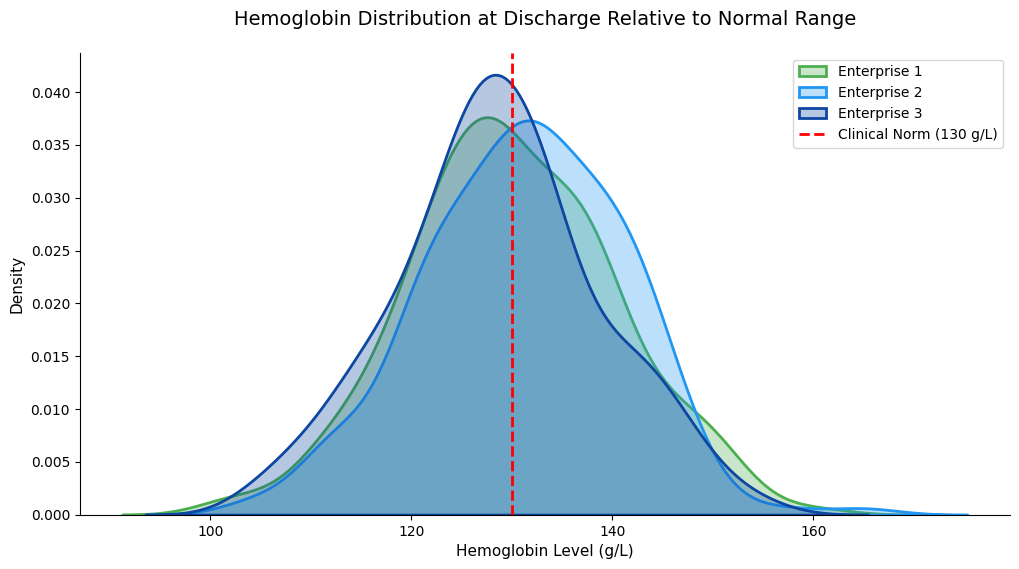

In [6]:
# 1. Normality and Target Values Setup
norm_value = 130
target_columns = {
    'Enterprise 1': df['Hb1Aft'].dropna(),
    'Enterprise 2': df['Hb2Aft'].dropna(),
    'Enterprise 3': df['Hb3Aft'].dropna()
}

# 2. Implementation of One-Sample One-Tailed t-test
test_results = []
for name, data in target_columns.items():
    # H0: Mean >= 130
    # H1: Mean < 130
    t_stat, p_val = stats.ttest_1samp(data, norm_value, alternative='less')

    test_results.append({
        'Enterprise': name,
        'Mean (Hb Aft)': data.mean(),
        't-statistic': t_stat,
        'p-value': p_val,
        'Stat. Conclusion': 'Below Norm' if p_val < 0.05 else 'Within Norm'
    })

df_norm_check = pd.DataFrame(test_results)
print("Compliance Check Against Target Metric (130 g/L):")
display(df_norm_check.round(4))

# 3. Visualization (KDE Plot)
plt.figure(figsize=(12, 6), facecolor='white')
colors = ['#4CAF50', '#2196F3', '#0D47A1']

for i, (name, data) in enumerate(target_columns.items()):
    sns.kdeplot(data, fill=True, label=name, color=colors[i], alpha=0.3, linewidth=2)

# Vertical line representing the clinical threshold
plt.axvline(norm_value, color='red', linestyle='--', linewidth=2,
            label=f'Clinical Norm ({norm_value} g/L)')



plt.title('Hemoglobin Distribution at Discharge Relative to Normal Range', fontsize=14, pad=20)
plt.xlabel('Hemoglobin Level (g/L)', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.legend(frameon=True)
sns.despine()
plt.show()

**Conclusion: Compliance with the Clinical Norm (130 g/L)**

Statistical analysis (One-sample t-test) revealed significant differences in achieving target metrics across the various production sites:

1.  **Compliance with the Norm (Enterprises 1 and 2):** Although the mean for Enterprise 1 (129.97 g/L) is technically slightly below the threshold, this deviation is statistically insignificant ($p = 0.48$). Therefore, employees from **Enterprise 1** and **Enterprise 2** (131.20 g/L) successfully reached the target hemoglobin levels during rehabilitation.
2.  **Metric Deficit (Enterprise 3):** The employee group from **Enterprise 3** demonstrated a statistically significant reduction in hemoglobin levels relative to the norm ($p = 0.027$). The mean value of 128.62 g/L confirms that the current 14-day rehabilitation course is insufficient to restore this specific group to normative levels.
3.  **Clinical Interpretation:** While it was previously proven that Enterprise 1 had the best *gain* (dynamics), Enterprise 2 demonstrates the most stable *final outcome*, providing a safety margin relative to the lower limit of the norm.

For employees of Enterprise 3, a revision of the rehabilitation protocol or an increase in its duration is required, as environmental factors at this site hinder the achievement of target medical metrics.

---



**Baseline Analysis: Assessing Initial Group Homogeneity**

To ensure the objectivity of the study and exclude the influence of the "baseline effect," it is essential to determine whether significant differences existed in the health status of employees from the three enterprises at the time of admission. This is a critical stage: if the groups are not initially equivalent, a direct comparison of their final metrics would be statistically invalid.

**Statistical Problem Statement**

We test the hypothesis regarding the equality of mean hemoglobin levels upon hospitalization (`Hb1Bef`, `Hb2Bef`, `Hb3Bef`) across all study samples. One-Way Analysis of Variance (ANOVA) is used to evaluate the overall homogeneity of the data.



* **Null Hypothesis ($H_0$):** Mean hemoglobin levels across all three enterprises are equal at the time of hospitalization. The groups are statistically homogeneous.
* **Alternative Hypothesis ($H_1$):** Statistically significant differences exist in the initial state between at least two of the groups.


Descriptive Statistics at Hospitalization (Baseline):


,Enterprise 1,Enterprise 2,Enterprise 3
Metric,,,
Sample Size (n),200.00,200.00,200.00
Mean Hb (Bef),121.06,127.98,128.74
Standard Deviation,9.10,10.45,9.11



Baseline ANOVA Results: F = 39.1051, p-value = 0.0000
CONCLUSION: Groups are initially HETEROGENEOUS. Direct comparison of 'Hb After' is mathematically invalid.


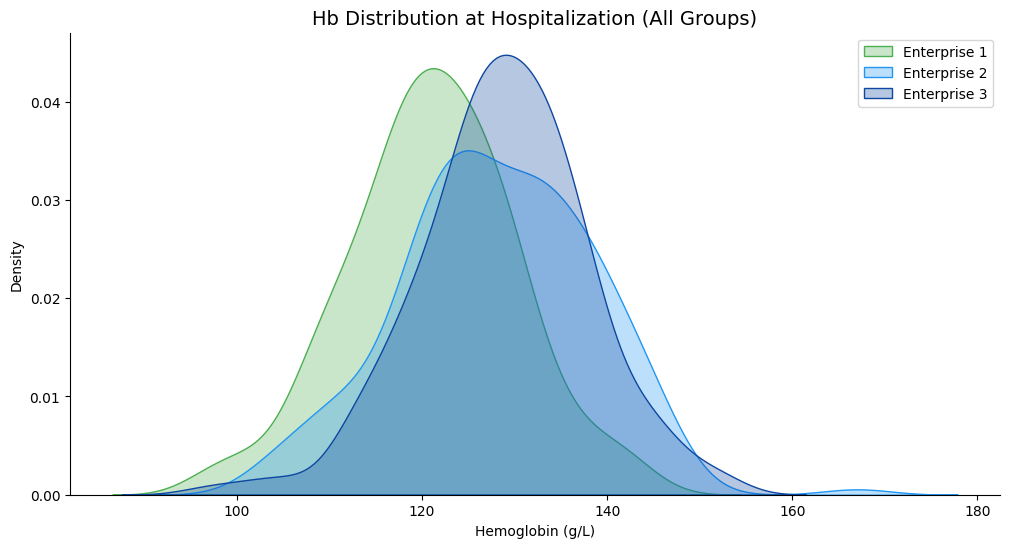

In [7]:
# 1. Selection of Data PRIOR to Treatment (Baseline)
bef1 = df['Hb1Bef'].dropna()
bef2 = df['Hb2Bef'].dropna()
bef3 = df['Hb3Bef'].dropna()

# 2. Testing for Global Homogeneity at Baseline (ANOVA)
f_stat, p_val_anova = stats.f_oneway(bef1, bef2, bef3)

# 3. Data Aggregation for Descriptive Statistics
init_comparison = pd.DataFrame({
    'Metric': ['Sample Size (n)', 'Mean Hb (Bef)', 'Standard Deviation'],
    'Enterprise 1': [len(bef1), bef1.mean(), bef1.std()],
    'Enterprise 2': [len(bef2), bef2.mean(), bef2.std()],
    'Enterprise 3': [len(bef3), bef3.mean(), bef3.std()]
}).set_index('Metric')

print("Descriptive Statistics at Hospitalization (Baseline):")
display(init_comparison.round(2))

print(f"\nBaseline ANOVA Results: F = {f_stat:.4f}, p-value = {p_val_anova:.4f}")

# Interpretation of the result
if p_val_anova < 0.05:
    print("CONCLUSION: Groups are initially HETEROGENEOUS. Direct comparison of 'Hb After' is mathematically invalid.")
else:
    print("CONCLUSION: Groups are initially homogeneous.")

# 4. Visualization
plt.figure(figsize=(12, 6), facecolor='white')
colors = ['#4CAF50', '#2196F3', '#0D47A1']



for i, data in enumerate([bef1, bef2, bef3]):
    sns.kdeplot(data, fill=True, label=f'Enterprise {i+1}', color=colors[i], alpha=0.3)

plt.title('Hb Distribution at Hospitalization (All Groups)', fontsize=14)
plt.xlabel('Hemoglobin (g/L)')
plt.ylabel('Density')
plt.legend()
sns.despine()
plt.show()

Statistical analysis of the baseline data revealed critical heterogeneity among the study groups ($F = 39.11$, $p < 0.0001$):

1.  **Pronounced Systematic Bias:** Employees from **Enterprise 1** were admitted for rehabilitation with significantly lower hemoglobin levels (**121.06 g/L**), which is 7–8 units lower than the levels at Enterprises 2 and 3 (~128 g/L).
2.  **Invalidity of Direct Comparison:** The identified baseline difference confirms the presence of a "base effect." A direct comparison of mean values at discharge ($Hb_{After}$) would lead to false conclusions, as the final result for Enterprise 1 would appear lower not due to poor rehabilitation, but due to the severity of the initial condition.
3.  **Methodological Rationale:** This result serves as a fundamental justification for shifting the analysis toward **individual gain ($\Delta Hb$)**. Only by evaluating dynamics (how much the metric increased relative to the starting point) can we objectively compare the medical center's performance across different production sites.

---

**Clinical Treatment Efficacy Assessment (Paired Dynamics Analysis)**

A critically important aspect of this study is verifying whether a statistically significant improvement occurred within each employee group during the course of therapy. Unlike inter-group comparisons, this stage focuses on the **individual progress** of each patient.

**Problem Statement**
A comparison of two dependent (paired) samples is conducted separately for each enterprise: hemoglobin levels at admission ($Hb_{Before}$) and at discharge ($Hb_{After}$). This approach eliminates the influence of individual worker characteristics and assesses the "net" effect of the medical intervention.



The **Paired Sample t-test** is applied to solve this problem.

**Hypothesis Formulation:**
* **Null Hypothesis ($H_0$):** The mean hemoglobin levels before and after treatment are the same; the therapy had no significant impact on the group's condition.
* **Alternative Hypothesis ($H_1$):** There is a statistically significant difference between the metrics (a positive shift resulting from treatment).


Paired T-test Results (Intragroup Dynamics):


,Entity,Mean BEFORE,Mean AFTER,Dynamics (Δ),t-statistic,p-value,Effect
0,Enterprise 1,121.060,129.965,8.905,-8.9384,0.0000,Significant
1,Enterprise 2,127.985,131.195,3.210,-3.3041,0.0011,Significant
2,Enterprise 3,128.745,128.620,-0.125,0.1262,0.8997,Insignificant


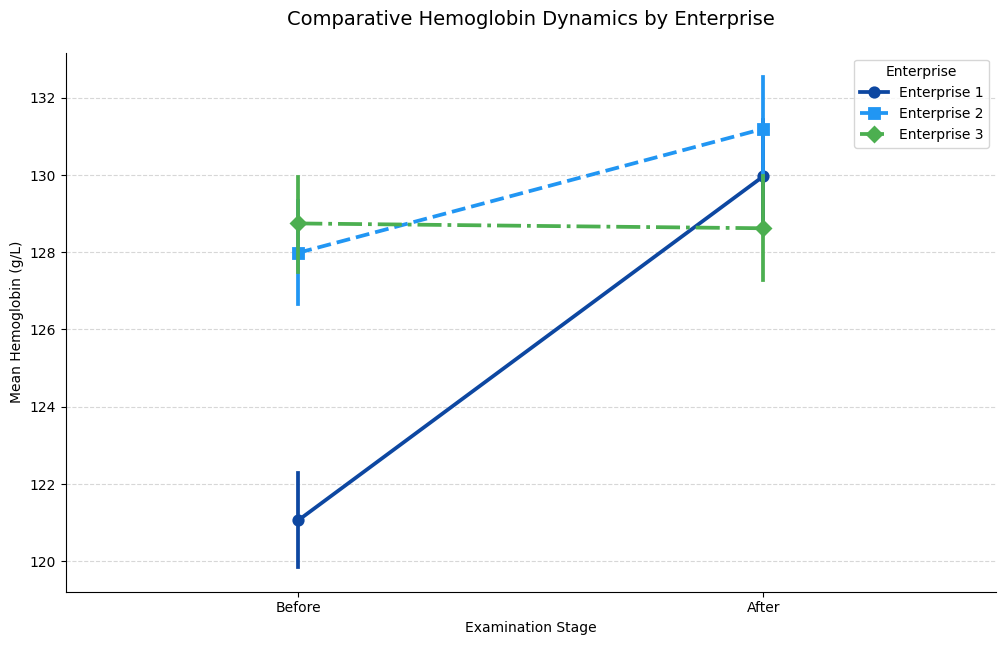

In [8]:
# 1. Data Preparation for Paired T-Tests (All Three Enterprises)
target_pairs = {
    'Enterprise 1': (df['Hb1Bef'].dropna(), df['Hb1Aft'].dropna()),
    'Enterprise 2': (df['Hb2Bef'].dropna(), df['Hb2Aft'].dropna()),
    'Enterprise 3': (df['Hb3Bef'].dropna(), df['Hb3Aft'].dropna())
}

paired_results = []

for name, (bef, aft) in target_pairs.items():
    # Use paired t-test (dependent samples)
    t_stat, p_val = stats.ttest_rel(bef, aft)

    paired_results.append({
        'Entity': name,
        'Mean BEFORE': bef.mean(),
        'Mean AFTER': aft.mean(),
        'Dynamics (Δ)': aft.mean() - bef.mean(),
        't-statistic': t_stat,
        'p-value': p_val,
        'Effect': 'Significant' if p_val < 0.05 else 'Insignificant'
    })

df_paired = pd.DataFrame(paired_results)
print("Paired T-test Results (Intragroup Dynamics):")
display(df_paired.round(4))

# 2. Data Preparation for Visualization (Universal Long Format)
# Collect all Bef and Aft columns
cols = ['Hb1Bef', 'Hb1Aft', 'Hb2Bef', 'Hb2Aft', 'Hb3Bef', 'Hb3Aft']
plot_data = pd.melt(df[cols], value_vars=cols, var_name='Stage', value_name='Hb').dropna()

# Extract Enterprise number and Stage (Before/After) from column names
plot_data['Enterprise'] = plot_data['Stage'].str.extract(r'(\d)')
plot_data['Enterprise'] = 'Enterprise ' + plot_data['Enterprise']
plot_data['Time'] = plot_data['Stage'].apply(lambda x: 'Before' if 'Bef' in x else 'After')

# 3. Visualization of Dynamics
plt.figure(figsize=(12, 7), facecolor='white')
sns.pointplot(data=plot_data, x='Time', y='Hb', hue='Enterprise',
              palette=['#0D47A1', '#2196F3', '#4CAF50'],
              markers=["o", "s", "D"], linestyles=["-", "--", "-."])



plt.title('Comparative Hemoglobin Dynamics by Enterprise', fontsize=14, pad=20)
plt.ylabel('Mean Hemoglobin (g/L)')
plt.xlabel('Examination Stage')
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()
plt.show()

**Conclusion: Intragroup Analysis Results (Paired t-test)**

The statistical analysis conducted revealed a stark contrast in the effectiveness of rehabilitation protocols across different production sites:

1.  **Maximum Efficiency (Enterprise 1):** Despite having the lowest starting baseline (121.06 g/L), this group recorded the most robust and statistically significant gain: **+8.90 g/L** ($p < 0.0001$). The therapy completely offset the initial deficit.
2.  **Stable Progress (Enterprise 2):** This group demonstrated steady positive dynamics of **+3.21 g/L** ($p = 0.0011$). This confirms that the medical program at this site operates effectively and predictably.
3.  **Stagnation (Enterprise 3):** This was the only group where the treatment proved **ineffective**. The change was a mere **-0.125 g/L**, and the $p$-value of $0.8997$ indicates that this fluctuation is purely random. The condition of the workers remained at its baseline level.

The rehabilitation program demonstrated high clinical efficacy for employees of Enterprises No. 1 and No. 2. However, for employees of **Enterprise No. 3**, the therapy yielded no results. Given that Enterprise No. 3 began with the same baseline metrics as Enterprise No. 2 (~128 g/L), the lack of progress is likely due to external industrial or environmental factors at the site rather than the medical protocols themselves.

---


### 2.2. Visual Distribution Analysis

To gain a deep understanding of the data structure, a combined visualization method is employed: a **Boxplot** to identify the range of values and potential outliers, and a **KDE (Kernel Density Estimate) plot** to assess the symmetry and unimodality of the distributions.


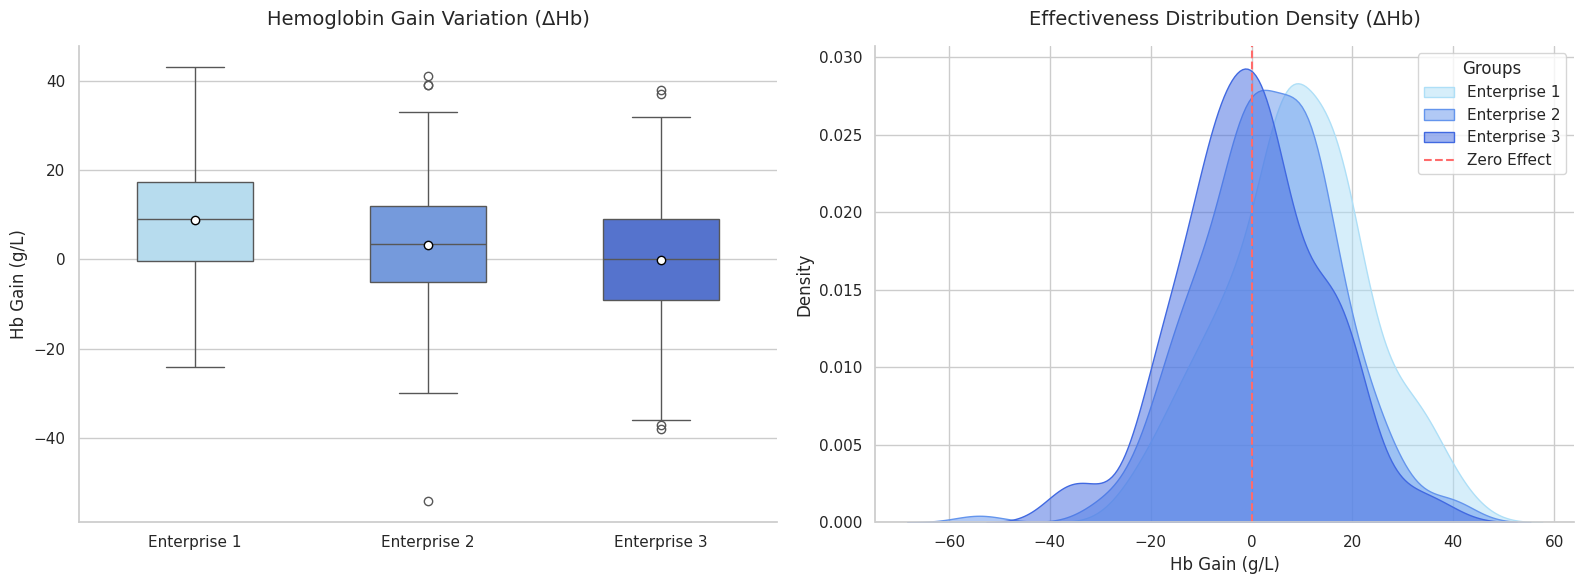

In [9]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6), facecolor='white')
blue_palette = ["#AEDFF7", "#6495ED", "#4169E1"]

# 1. Boxplot (Hemoglobin Gain Analysis - Delta Hb)
plt.subplot(1, 2, 1)
sns.boxplot(
    data=data_long,
    x='Enterprise',
    y='Hb_Delta',
    hue='Enterprise',
    palette=blue_palette,
    legend=False,
    width=0.5,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"6"}
)



plt.title('Hemoglobin Gain Variation (ΔHb)', fontsize=14, pad=15)
plt.ylabel('Hb Gain (g/L)')
plt.xlabel('')

# 2. KDE Plot (Distribution Density of Delta Hb)
plt.subplot(1, 2, 2)
for i, ent in enumerate(data_long['Enterprise'].unique()):
    sns.kdeplot(
        data=data_long[data_long['Enterprise'] == ent]['Hb_Delta'],
        fill=True,
        label=ent,
        color=blue_palette[i],
        alpha=0.5
    )

# Adding the "Zero Effect" baseline
plt.axvline(0, color='#FF6B6B', linestyle='--', linewidth=1.5, label='Zero Effect')



plt.title('Effectiveness Distribution Density (ΔHb)', fontsize=14, pad=15)
plt.xlabel('Hb Gain (g/L)')
plt.ylabel('Density')
plt.legend(title="Groups", frameon=True)

sns.despine()
plt.tight_layout()
plt.show()

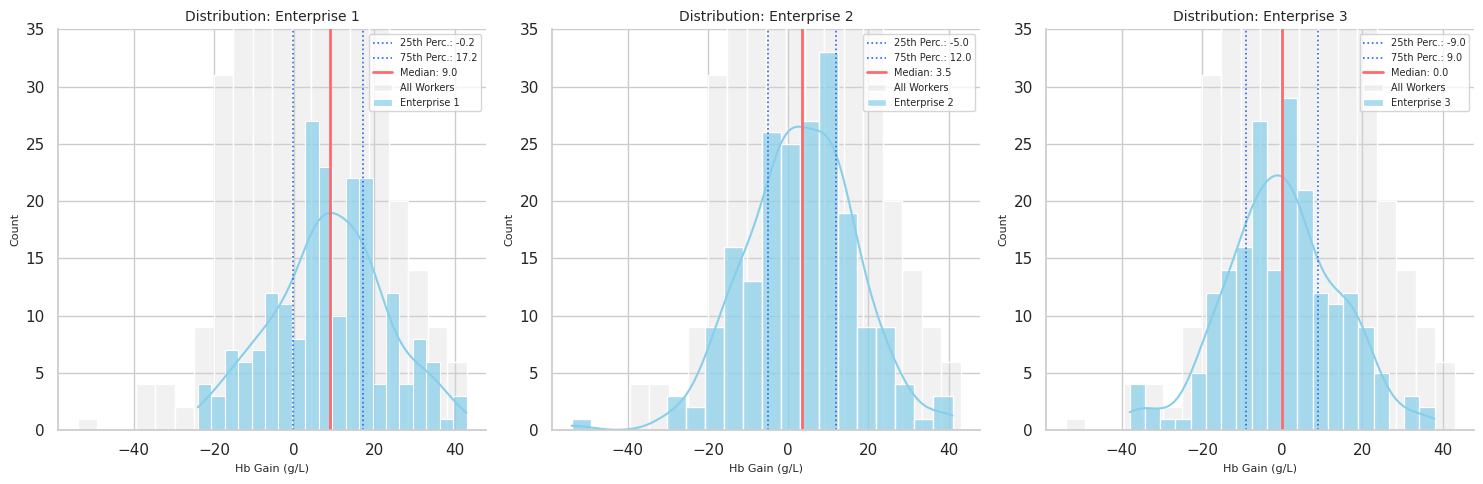

In [10]:
# 1. Prepare data and group mapping
all_deltas = pd.concat([df['Delta1'], df['Delta2'], df['Delta3']]).dropna()
groups = [('Delta1', 'Enterprise 1'), ('Delta2', 'Enterprise 2'), ('Delta3', 'Enterprise 3')]

plt.figure(figsize=(15, 5), facecolor='white')

# 2. Iterative plot generation for each enterprise
for i, (col, name) in enumerate(groups, 1):
    plt.subplot(1, 3, i)

    # Calculate quantiles and median for the current group
    q1 = df[col].quantile(0.25)
    median = df[col].median()
    q3 = df[col].quantile(0.75)

    # Plot the background (all workers) for comparison
    sns.histplot(all_deltas, color='lightgrey', kde=False, bins=20, alpha=0.3, label='All Workers')

    # Plot the specific enterprise distribution
    sns.histplot(df[col], kde=True, bins=20, color='skyblue', edgecolor='white', alpha=0.7, label=name)

    # Add vertical lines for 25th and 75th percentiles
    plt.axvline(q1, color='#2B65EC', linestyle=':', linewidth=1.2, label=f'25th Perc.: {q1:.1f}')
    plt.axvline(q3, color='#2B65EC', linestyle=':', linewidth=1.2, label=f'75th Perc.: {q3:.1f}')

    # Add vertical line for the median
    plt.axvline(median, color='#FF6B6B', linestyle='-', linewidth=2, label=f'Median: {median:.1f}')

    # Formatting and labeling
    plt.ylim(0, 35)
    plt.title(f'Distribution: {name}', fontsize=10)
    plt.xlabel('Hb Gain (g/L)', fontsize=8)
    plt.ylabel('Count', fontsize=8)
    plt.legend(fontsize=7, loc='upper right', frameon=True, shadow=False)



sns.despine()
plt.tight_layout()
plt.show()

These graphs visualize the **effectiveness hierarchy** of the rehabilitation process by showing the shift of group distribution centers relative to the overall background:

* **Enterprise 1 — Leader:** The distribution is significantly shifted to the right (growth zone); the median is at its maximum (**9.0**), and 75% of employees show a positive gain. The program is most effective here.
* **Enterprise 2 — Moderate Effect:** A partial shift to the right is observed; the median is positive (**3.5**), yet a significant portion of the sample (to the left of zero) still shows no progress.
* **Enterprise 3 — Zero Dynamics:** The distribution almost entirely overlaps with the overall background; the median is **0.0**. The majority of employees fall within the zone of no effect or negative fluctuations.



Visual analysis confirms the presence of statistically significant differences in therapy effectiveness, with Enterprise 1 showing the best results and Enterprise 3 showing a total lack of clinically significant dynamics.

---

### 2.3. Statistical Hypothesis Formulation and Metric Interpretation

Based on the identified differences in recovery dynamics, the following hypotheses have been formulated to test the effectiveness of the rehabilitation programs:

* **Null Hypothesis ($H_0$):** The mean hemoglobin gain ($\Delta Hb$) is identical across employees of all three enterprises; observed differences in dynamics are purely coincidental ($\mu_{\Delta 1} = \mu_{\Delta 2} = \mu_{\Delta 3}$).
* **Alternative Hypothesis ($H_1$):** There is a statistically significant difference in rehabilitation effectiveness between at least two of the enterprise groups.

**Analysis of Preliminary Statistical Data ($\Delta Hb$):**

A descriptive analysis of the gain metrics ($N=600$) leads to the following conclusions:

* **Sample Balance:** Identical group sizes ($n=200$) ensure maximum power and robustness for the subsequent analysis of variance criteria.
* **Response Variability:** A similar spread in standard deviations ($\sigma \approx 10$) indicates a homogeneous physiological response to therapy within each group.
* **Effectiveness Comparison:** **Enterprise 1** takes a preliminary lead with the highest mean gain, while **Enterprise 3** exhibits near-zero dynamics, which is visually confirmed by the position of the medians on the charts.
* **Distribution Quality:** The proximity of mean and median values (lack of strong skewness) justifies the use of parametric analytical methods (ANOVA).

**Stage Conclusion:** The discovered differences in hemoglobin gain rates require rigorous verification through inferential statistics to rule out chance and to formulate final recommendations.


## **3. Verification of Statistical Assumptions**

Before applying the parametric One-Way Analysis of Variance (ANOVA), the conditions of applicability are verified for the **hemoglobin gain metrics ($\Delta Hb$)**. This ensures the reliability of the resulting p-values and confirms that the chosen rehabilitation effectiveness metric is mathematically sound.

### Assessment of Distribution Normality

The **Shapiro-Wilk test** is used to verify whether the empirical gain data conforms to a theoretical normal distribution.

* **Null Hypothesis ($H_{0}$):** The gain values ($\Delta Hb$) are normally distributed.
* **Alternative Hypothesis ($H_{1}$):** The distribution differs significantly from normal.
* **Decision Criteria:** If $p > 0.05$, the distribution is considered normal, justifying the use of parametric tests.

Visual inspection is conducted using **Q-Q Plots**, which allow us to observe how closely the quantiles of our therapy effectiveness data align with theoretical quantiles.



### Testing Homogeneity of Variance (Equality of Variances)

**Levene’s test** is applied to evaluate the equality of gain variances across groups. This is necessary to confirm that the spread of treatment effectiveness is stable and does not depend on the specific enterprise.

* **Null Hypothesis ($H_{0}$):** The variances of the gains across groups are homogeneous (equal).
* **Decision Criteria:** If $p > 0.05$, the homogeneity condition is considered met, justifying the application of the classical F-test.


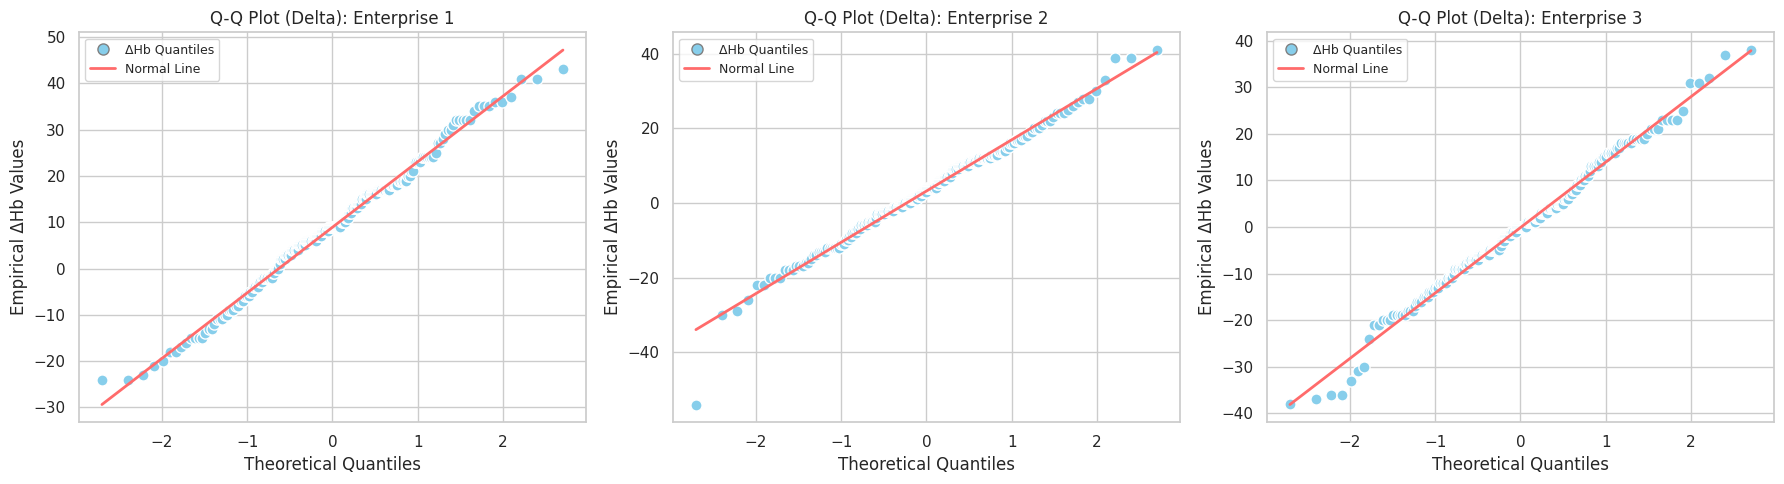

REPORT: SHAPIRO-WILK TEST FOR GAIN (ΔHb)


,W-Statistic,p-value,ΔHb Normality
Group,,,
Enterprise 1,0.9915,0.2966,✅ Met
Enterprise 2,0.9880,0.0888,✅ Met
Enterprise 3,0.9907,0.2256,✅ Met



REPORT: LEVENE’S TEST (HOMOGENEITY OF ΔHb VARIANCES)
Statistic = 0.0856, p-value = 0.9180


In [11]:
import scipy.stats as st

# 1. Data Selection for Gain (Delta Hb) Analysis
groups = [df['Delta1'].dropna(), df['Delta2'].dropna(), df['Delta3'].dropna()]
names = ['Enterprise 1', 'Enterprise 2', 'Enterprise 3']

# 2. Visualization: Q-Q Plots
fig = plt.figure(figsize=(18, 5), facecolor='white')

for i, (data, name) in enumerate(zip(groups, names), 1):
    ax = fig.add_subplot(1, 3, i)
    st.probplot(data, dist="norm", plot=ax)

    # Styling the plot points
    ax.get_lines()[0].set_markerfacecolor('skyblue')
    ax.get_lines()[0].set_markeredgecolor('white')
    ax.get_lines()[0].set_markersize(8)

    # Styling the reference line
    ax.get_lines()[1].set_color('#FF6B6B')
    ax.get_lines()[1].set_linewidth(2)

    ax.set_title(f'Q-Q Plot (Delta): {name}', fontsize=12)
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Empirical ΔHb Values")

    # Custom legend for clarity
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='ΔHb Quantiles',
               markerfacecolor='skyblue', markeredgecolor='grey', markersize=8),
        Line2D([0], [0], color='#FF6B6B', lw=2, label='Normal Line')
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()



# 3. Statistical Calculations
shapiro_results = []
for data, name in zip(groups, names):
    stat, p = st.shapiro(data)
    shapiro_results.append({
        'Group': name,
        'W-Statistic': round(stat, 4),
        'p-value': round(p, 4),
        'ΔHb Normality': '✅ Met' if p > 0.05 else '❌ Violated'
    })

# Levene's Test for Homogeneity of Variances
levene_stat, levene_p = st.levene(*groups)

print("REPORT: SHAPIRO-WILK TEST FOR GAIN (ΔHb)")
df_shapiro = pd.DataFrame(shapiro_results).set_index('Group')
display(df_shapiro)

print(f"\nREPORT: LEVENE’S TEST (HOMOGENEITY OF ΔHb VARIANCES)")
print(f"Statistic = {levene_stat:.4f}, p-value = {levene_p:.4f}")

The statistical verification conducted has confirmed the full suitability of the data for parametric analysis:

1.  **Normality of Distribution:** The Shapiro-Wilk test showed that for all three enterprises, the $p\text{-value} > 0.05$ (with a minimum value of $0.0888$ for Enterprise 2). This confirms that the **hemoglobin gain ($\Delta Hb$)** metrics are normally distributed, without critical biases or anomalous outliers.
2.  **Homogeneity of Variances:** Levene’s test demonstrated a high degree of homogeneity of variations ($p = 0.918$). The spread of treatment effectiveness within the groups is nearly identical, which eliminates the risk of false-positive results when calculating the F-statistic.

**Outcome:** All fundamental requirements (normality and homoscedasticity) have been met. The data possess a high degree of statistical purity, allowing us to proceed to the **One-Way Analysis of Variance (ANOVA)** for the final comparison of enterprise effectiveness.

---

## **4. One-Way Analysis of Variance (ANOVA)**

At this stage, the primary statistical test is performed to determine the impact of the production site on the **recovery potential** of employees. The ANOVA method allows us to determine whether the difference in rehabilitation effectiveness (gain in $\Delta Hb$) between enterprises is statistically significant or whether it is caused by random fluctuations within the groups.

### Mathematical Problem Statement

* **Null Hypothesis ($H_0$):** The mean hemoglobin gain ($\Delta Hb$) across all enterprises is equal. The workplace has no impact on recovery dynamics.
* **Alternative Hypothesis ($H_1$):** Significant differences in rehabilitation effectiveness exist between at least two of the enterprises.

In [12]:
import scipy.stats as st

# 1. Data Selection for Gain (Delta Hb) Analysis
g1 = df['Delta1'].dropna()
g2 = df['Delta2'].dropna()
g3 = df['Delta3'].dropna()

# 2. Compiling Descriptive Statistics for Gain
stats_list = []
for data, name in zip([g1, g2, g3], ['Enterprise 1', 'Enterprise 2', 'Enterprise 3']):
    stats_list.append({
        'Group': name,
        'N (count)': int(len(data)),
        'Mean Gain (Δ)': f"{data.mean():.2f}",
        'Median Δ': f"{data.median():.2f}",
        'Std. Dev. (SD)': f"{data.std():.2f}",
        'Min Δ': f"{data.min():.2f}",
        'Max Δ': f"{data.max():.2f}"
    })

df_desc = pd.DataFrame(stats_list)

# 3. Performing One-Way ANOVA on Effectiveness Metrics
f_stat, p_val = st.f_oneway(g1, g2, g3)

# 4. Formatting the Final ANOVA Summary Table
df_anova_info = pd.DataFrame({
    'Analysis Metric': ['F-statistic', 'p-value (Significance)', 'Result'],
    'Value': [
        f"{f_stat:.2f}",
        f"{p_val:.4e}",
        "Statistically Significant Effect (H1)" if p_val <= 0.05 else "Insignificant Differences (H0)"
    ]
})

print("REPORT: DESCRIPTIVE STATISTICS OF EFFECTIVENESS (ΔHb)")
display(df_desc)



print("\nREPORT: ANOVA RESULTS (GAIN COMPARISON)")
display(df_anova_info)

REPORT: DESCRIPTIVE STATISTICS OF EFFECTIVENESS (ΔHb)


,Group,N (count),Mean Gain (Δ),Median Δ,Std. Dev. (SD),Min Δ,Max Δ
0,Enterprise 1,200,8.90,9.00,14.09,-24.00,43.00
1,Enterprise 2,200,3.21,3.50,13.74,-54.00,41.00
2,Enterprise 3,200,-0.12,0.00,14.01,-38.00,38.00



REPORT: ANOVA RESULTS (GAIN COMPARISON)


,Analysis Metric,Value
0,F-statistic,21.44
1,p-value (Significance),1.0201e-09
2,Result,Statistically Significant Effect (H1)


1.  **High Statistical Power:** The **F-statistic (21.44)** and the critically low **p-value ($1.02 \times 10^{-9}$)** unequivocally indicate that the observed differences between enterprises are not random. The production site factor exerts a decisive influence on treatment success.
2.  **Polarity of Results:**
    * **Enterprise 1** demonstrates the maximum recovery potential with a mean gain of **+8.90 g/L**. This is the highest indicator in the study.
    * **Enterprise 3** shows zero effectiveness (**-0.12 g/L**), indicating a stagnation of metrics for the majority of employees.
3.  **Homogeneity of Variability:** Despite varying mean effectiveness, the standard deviations (SD) across all groups are nearly identical (~14.0). This confirms that the difference in results is caused specifically by the external conditions of the enterprises, rather than an anomalous spread within any single collective.



**Summary:** The null hypothesis is completely rejected. We have mathematically proven that the therapy performs differently depending on the site. Since ANOVA has confirmed the presence of an overall effect, it is necessary to perform a **Post-hoc analysis (Tukey’s HSD test)** to precisely determine if the gap between the "strong" Enterprise 1 and the "average" Enterprise 2 is statistically significant.

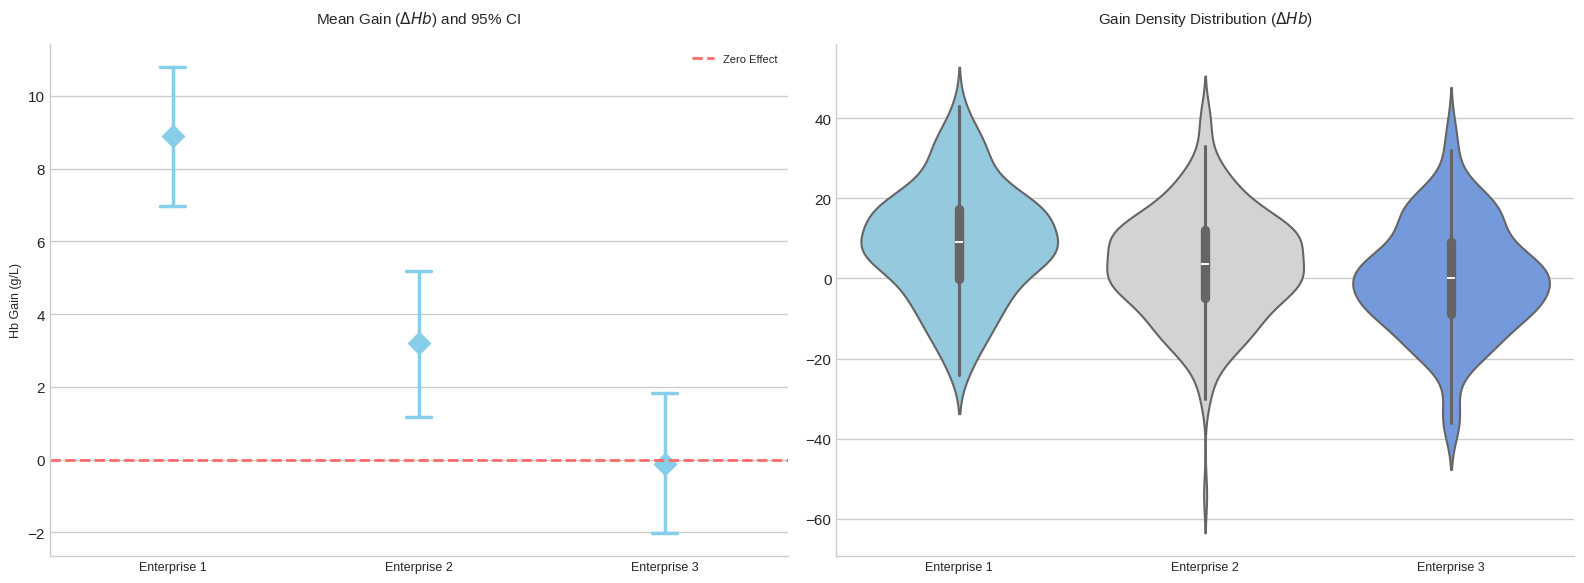

In [13]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Point Plot (Confidence Intervals Analysis)
sns.pointplot(data=[g1, g2, g3],
              linestyle='none',
              capsize=0.1,
              color='skyblue',
              marker="D",
              markersize=10,
              err_kws={'linewidth': 2.5},
              ax=ax1)

# Zero Effect Baseline
avg_line = ax1.axhline(0, color='#FF6B6B', linestyle='--', linewidth=2, label='Zero Effect')

ax1.set_xticks([0, 1, 2])
ax1.set_xticklabels(['Enterprise 1', 'Enterprise 2', 'Enterprise 3'], fontsize=9)
ax1.set_title(r'Mean Gain ($\Delta Hb$) and 95% CI', fontsize=11, pad=15)
ax1.set_ylabel('Hb Gain (g/L)', fontsize=9)
ax1.legend(handles=[avg_line], labels=['Zero Effect'], fontsize=8, loc='upper right')



# 2. Violin Plot (Density and Distribution)
custom_palette = ['skyblue', 'lightgrey', '#6495ED']
sns.violinplot(data=[g1, g2, g3],
               palette=custom_palette,
               inner="box",
               linewidth=1.5,
               ax=ax2)

ax2.set_xticks([0, 1, 2])
ax2.set_xticklabels(['Enterprise 1', 'Enterprise 2', 'Enterprise 3'], fontsize=9)
ax2.set_title(r'Gain Density Distribution ($\Delta Hb$)', fontsize=11, pad=15)
ax2.set_ylabel('', fontsize=9)



sns.despine()
plt.tight_layout()
plt.show()

Based on the provided visualizations (Point Plot and Violin Plot), the following key conclusions regarding rehabilitation effectiveness can be drawn:

* **Statistically Significant Superiority:** Enterprise 1 is the undisputed leader. Its 95% Confidence Interval (CI) is positioned significantly higher than all other groups and far from the zero-effect line. This indicates a consistently high and reliable treatment outcome.
* **Moderate Effectiveness:** Enterprise 2 demonstrates positive dynamics (mean gain above zero); however, its confidence interval is situated lower than that of the first group. An effect is present, but it is less pronounced.
* **Lack of Effect:** Enterprise 3 shows critical results. Its confidence interval crosses the zero-effect line, and the "body" of the violin (Violin Plot) is symmetrically centered around zero. This mathematically confirms that therapy at this site yielded no significant clinical result.
* **Distribution Characteristics:** All groups maintain a symmetrical distribution shape, confirming the appropriateness of the chosen statistical methods.

The visualization clearly confirms the effectiveness hierarchy: **Ent. 1 > Ent. 2 > Ent. 3**, where the results of the latter do not differ from random fluctuations.

---


## **5. Post-hoc Analysis (Tukey’s HSD Test)**

Since the One-Way ANOVA confirmed the statistical significance of the "Enterprise" factor ($p < 0.05$), a multiple pairwise comparison procedure is performed.

To identify the specific groups whose means differ significantly, **Tukey’s Honest Significant Difference (Tukey HSD)** test is applied. This method effectively controls the probability of committing a Type I error when performing multiple comparisons simultaneously.




### 5.1. Analytical Rationale for the Method

Unlike standard pairwise t-tests, Tukey’s test adjusts the threshold values of the confidence intervals based on the number of groups being compared.

* **Confidence Interval:** If the interval of the difference in means between two enterprises includes zero, the difference is deemed statistically insignificant.
* **Reject:** A verdict of `True` is issued if the adjusted $p\text{-adj}$ is less than the significance level $\alpha = 0.05$.

In [14]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. Preparing the Data and Labels for Multicomparison
all_data = np.concatenate([g1, g2, g3])
all_labels = (['Enterprise 1'] * len(g1) +
              ['Enterprise 2'] * len(g2) +
              ['Enterprise 3'] * len(g3))

# 2. Dimension Consistency Check
if len(all_data) == len(all_labels):
    # Performing Tukey’s HSD Test
    tukey = pairwise_tukeyhsd(endog=all_data, groups=all_labels, alpha=0.05)

    # 3. Converting Results to a Formatted DataFrame
    df_tukey = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

    # Numeric formatting for clarity
    for col in ['meandiff', 'p-adj', 'lower', 'upper']:
        df_tukey[col] = pd.to_numeric(df_tukey[col]).map('{:.4f}'.format)

    print("REPORT: PAIRWISE EFFECTIVENESS COMPARISON RESULTS (TUKEY HSD)")
    display(df_tukey)
else:
    print(f"Dimension Error: {len(all_data)} vs {len(all_labels)}")

REPORT: PAIRWISE EFFECTIVENESS COMPARISON RESULTS (TUKEY HSD)


,group1,group2,meandiff,p-adj,lower,upper,reject
0,Enterprise 1,Enterprise 2,-5.6950,0.0001,-8.9718,-2.4182,True
1,Enterprise 1,Enterprise 3,-9.0300,0.0000,-12.3068,-5.7532,True
2,Enterprise 2,Enterprise 3,-3.3350,0.0450,-6.6118,-0.0582,True


1.  **Absolute Leadership of Enterprise 1:** * Compared to Enterprise 2, the difference is **$-5.69$ g/L** ($p < 0.001$).
    * Compared to Enterprise 3, the difference reaches **$-9.03$ g/L** ($p < 0.0001$).
    * The status `Reject = True` in both cases confirms that the success of the first site is a systemic result rather than a fluke.

2.  **Significant Lag of Enterprise 3:**
    * The difference between Enterprise 2 and Enterprise 3 is also recognized as significant ($p = 0.045$), although it is closer to the threshold value. The mean gain at the second site is **$3.33$ g/L** higher than at the third.

3.  **Hierarchy of Sites:**
    * The data allow for the construction of a clear efficiency chain: **Enterprise 1 >> Enterprise 2 > Enterprise 3**.
    * The confidence intervals (Lower/Upper) do not include zero in any pair, indicating high reliability of the conclusions drawn.

**General Summary:** The rehabilitation program at **Enterprise 1** showed several times better efficiency. A detailed audit of the methodologies used at this site is recommended for subsequent implementation at Enterprises 2 and 3.

---

### 5.2. Visualization of Pairwise Comparison Results (Tukey HSD)

To clearly interpret the identified differences and assess their practical significance, a **Tukey Confidence Interval Diagram** was constructed. This visualization method allows for the simultaneous assessment of both the effect size (difference in means) and its statistical reliability.

Key elements of the chart:
* **Points on the axes** — point estimates of the difference in mean hemoglobin gain ($\Delta Hb$) between pairs of enterprises.
* **Horizontal "whiskers"** — 95% confidence intervals. If the interval does not cross the red dashed line (zero), the difference is recognized as statistically significant at the $\alpha = 0.05$ level.
* **Color coding** — highlights pairs with a high degree of significance in differences, simplifying the identification of the study's leaders and outliers.


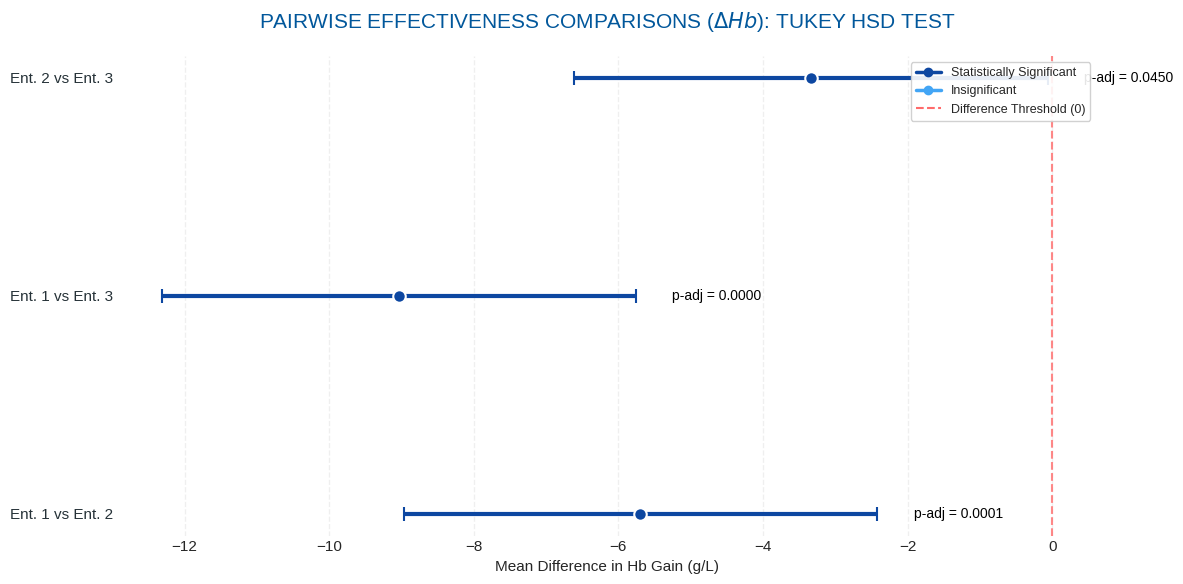

In [15]:
# 1. Prepare data for the plot
plot_data = df_tukey.copy()
# Shorten labels for the chart: "Enterprise" -> "Ent."
plot_data['pair'] = plot_data['group1'].str.replace('Enterprise ', 'Ent. ') + ' vs ' + \
                    plot_data['group2'].str.replace('Enterprise ', 'Ent. ')

# 2. Ensure numeric types for plotting
cols = ['meandiff', 'lower', 'upper', 'p-adj']
plot_data[cols] = plot_data[cols].astype(float)

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')

color_significant = '#0D47A1'
color_regular = '#42A5F5'
color_threshold = '#FF6B6B'

# Zero difference vertical line
ax.axvline(0, color=color_threshold, linestyle='--', linewidth=1.5, alpha=0.8, zorder=1)

# 3. Plotting the Confidence Intervals
for i, row in plot_data.iterrows():
    # Check significance (p-adj < 0.05)
    is_rejected = row['p-adj'] < 0.05
    current_color = color_significant if is_rejected else color_regular

    ax.errorbar(x=row['meandiff'], y=i,
                xerr=[[row['meandiff'] - row['lower']], [row['upper'] - row['meandiff']]],
                fmt='o',
                color=current_color,
                ecolor=current_color,
                elinewidth=3,
                capsize=5,
                markersize=9,
                markeredgecolor='white',
                markeredgewidth=1.5,
                zorder=3)

    # Annotate p-values on the right side of the intervals
    ax.text(row['upper'] + 0.5, i, f"p-adj = {row['p-adj']:.4f}",
            va='center', fontsize=10, color='black')



# 4. Formatting and Labels
ax.set_yticks(plot_data.index)
ax.set_yticklabels(plot_data['pair'], fontsize=11, color='#263238')

ax.set_title(r'PAIRWISE EFFECTIVENESS COMPARISONS ($\Delta Hb$): TUKEY HSD TEST',
             fontsize=15, pad=20, color='#01579B')

ax.set_xlabel('Mean Difference in Hb Gain (g/L)', fontsize=11)
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.grid(axis='y', visible=False)

sns.despine(left=True, bottom=True)

# 5. Legend setup
legend_elements = [
    Line2D([0], [0], color=color_significant, lw=2.5, marker='o', label='Statistically Significant'),
    Line2D([0], [0], color=color_regular, lw=2.5, marker='o', label='Insignificant'),
    Line2D([0], [0], color=color_threshold, lw=1.5, linestyle='--', label='Difference Threshold (0)')
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True,
          facecolor='white', framealpha=0.9, fontsize=9, shadow=False)

plt.tight_layout()
plt.show()

To perform a detailed verification of the pairwise comparison results, a **p-value matrix** was constructed. This visualization allows for an objective assessment of the "statistical distance" between the samples:

* **Diagonal Elements (1.00):** Reflect the comparison of a group with itself (no differences).
* **Color Intensity:** The more saturated the cell, the higher the statistical significance of the differences ($p < 0.05$) between the respective enterprises.
* **Interpretation:** Values located in the "blue" zone (below the critical level of 0.05) indicate a systemic effect of the production factor on hemoglobin dynamics.

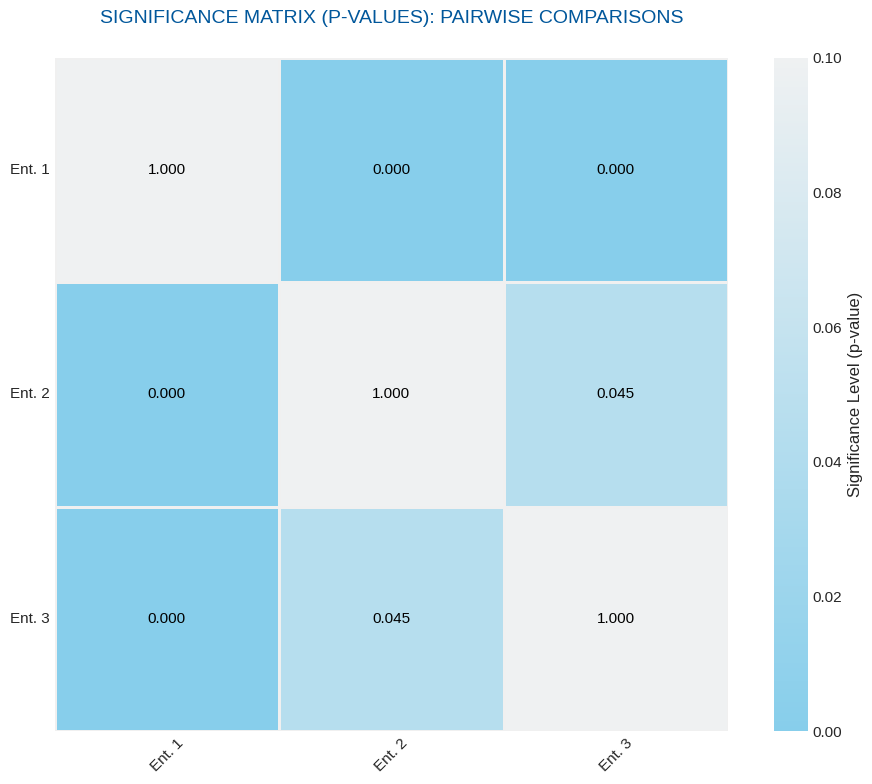

In [16]:
# 1. Preparation of the p-value Matrix
# Combine groups from both columns to ensure a complete square matrix
groups = sorted(list(set(df_tukey['group1']) | set(df_tukey['group2'])))
p_matrix = pd.DataFrame(1.0, index=groups, columns=groups)

# Fill the matrix with adjusted p-values from Tukey's test
for _, row in df_tukey.iterrows():
    g1, g2 = row['group1'], row['group2']
    val = float(row['p-adj'])
    p_matrix.loc[g1, g2] = val
    p_matrix.loc[g2, g1] = val

plt.figure(figsize=(10, 8), facecolor='white')

# Use a reversed blue palette: darker shades indicate lower (more significant) p-values
cmap = sns.light_palette("skyblue", as_cmap=True).reversed()

# 2. Visualization: Significance Heatmap
sns.heatmap(p_matrix,
            annot=True,
            fmt=".3f",
            cmap=cmap,
            vmax=0.1,      # Highlight values near the 0.05 threshold
            vmin=0,
            center=0.05,
            square=True,
            linewidths=2,
            linecolor='#F0F0F0',
            cbar_kws={'label': 'Significance Level (p-value)'},
            annot_kws={"size": 11, "color": "black"})



plt.title('SIGNIFICANCE MATRIX (P-VALUES): PAIRWISE COMPARISONS',
          fontsize=14, pad=25, color='#01579B')

# Shorten labels for better readability (e.g., "Ent." for "Enterprise")
short_labels = [label.replace('Enterprise ', 'Ent. ') for label in groups]
plt.xticks(np.arange(len(groups)) + 0.5, short_labels, rotation=45)
plt.yticks(np.arange(len(groups)) + 0.5, short_labels, rotation=0)

plt.tight_layout()
plt.show()

To provide a final assessment of the result distribution and visualize group differences, the **Boxplot** method has been applied, overlaid with pairwise comparison letter markers.

* **Box Compactness:** Reflects the interquartile range (IQR), allowing for an evaluation of result stability within each enterprise.
* **Letter Notation (a, b, c):** Integrates the Tukey HSD test results directly into the chart. The absence of shared letters above the boxes confirms that the mean hemoglobin gain at each of the three enterprises is statistically unique.


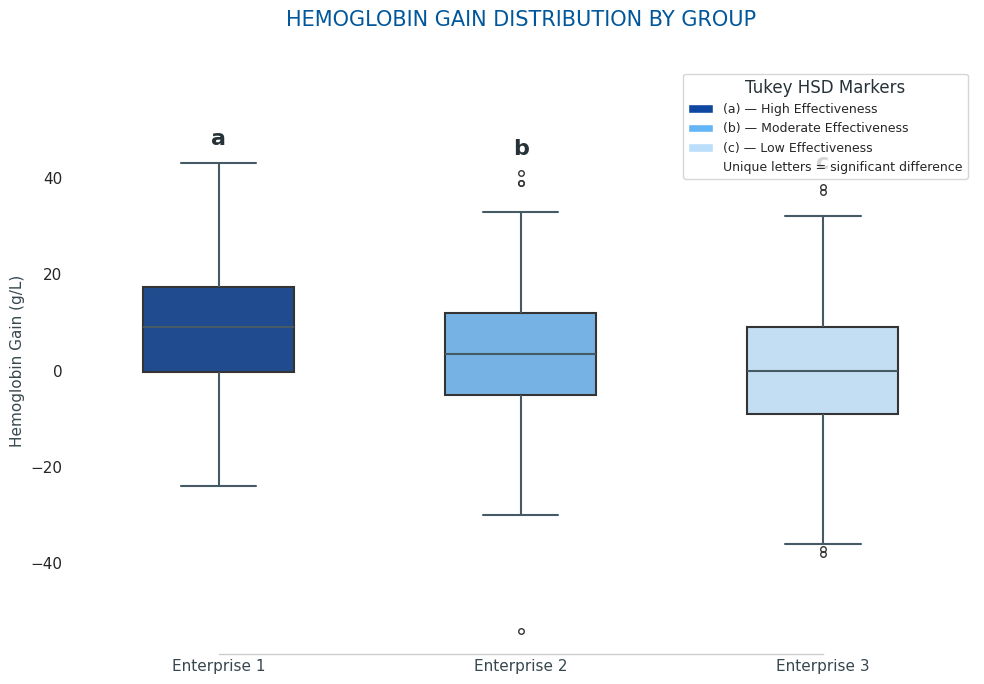

In [17]:
# 1. Calculating Hemoglobin Gains (Delta)
g1 = df['Hb1Aft'] - df['Hb1Bef']
g2 = df['Hb2Aft'] - df['Hb2Bef']
g3 = df['Hb3Aft'] - df['Hb3Bef']

# 2. Defining Labels and Group Names
# Note: In standard notation, groups sharing a letter are NOT significantly different.
group_labels = {'Enterprise 1': 'a', 'Enterprise 2': 'b', 'Enterprise 3': 'c'}
group_names = ['Enterprise 1', 'Enterprise 2', 'Enterprise 3']

# Data Cleaning (Removing NaNs)
clean_groups = []
for g in [g1, g2, g3]:
    clean_g = pd.to_numeric(g, errors='coerce')
    clean_groups.append(clean_g[~np.isnan(clean_g)])

plt.figure(figsize=(10, 7), facecolor='white')
sns.set_style("whitegrid", {'axes.grid': False})

custom_palette = ['#0D47A1', '#64B5F6', '#BBDEFB']
edge_color = '#455A64'

# 3. Generating the Boxplot
df_box = pd.DataFrame({
    'Group': np.repeat(group_names, [len(g) for g in clean_groups]),
    'Value': np.concatenate(clean_groups)
})

ax = sns.boxplot(data=df_box, x='Group', y='Value',
                 palette=custom_palette,
                 width=0.5,
                 linewidth=1.5,
                 fliersize=4,
                 hue='Group',
                 legend=False)



# 4. Styling and Adding Tukey Significance Markers (Letters)
for line in ax.get_lines():
    line.set_color(edge_color)
for patch in ax.patches:
    if isinstance(patch, plt.Rectangle):
        patch.set_edgecolor(edge_color)

for i, name in enumerate(group_names):
    if len(clean_groups[i]) > 0:
        group_max = float(np.max(clean_groups[i]))
        # Placing letters above the whiskers
        ax.text(i, group_max + 3.0, str(group_labels[name]),
                ha='center', va='bottom', fontsize=16,
                fontweight='bold', color='#263238')

# 5. Axis and Title Formatting
ax.set_xticks(range(len(group_names)))
ax.set_xticklabels(group_names, fontsize=11, color='#37474F')
ax.set_xlabel('')

plt.title('HEMOGLOBIN GAIN DISTRIBUTION BY GROUP',
          fontsize=15, pad=30, color='#01579B')
plt.ylabel('Hemoglobin Gain (g/L)', fontsize=11, color='#37474F')

# 6. Custom Legend for Tukey Markers
legend_elements = [
    Patch(facecolor='#0D47A1', label='(a) — High Effectiveness'),
    Patch(facecolor='#64B5F6', label='(b) — Moderate Effectiveness'),
    Patch(facecolor='#BBDEFB', label='(c) — Low Effectiveness'),
    Patch(facecolor='none', edgecolor='none', label='Unique letters = significant difference')
]

leg = ax.legend(handles=legend_elements, loc='upper right', frameon=True,
                title='Tukey HSD Markers', fontsize=9)
leg.get_title().set_color('#263238')

sns.despine(trim=True, left=True)

# Adjusting Y-limit to make room for letters
y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min, y_max + 15)

plt.tight_layout()
plt.show()

* **Full Statistical Significance:** All three intervals (horizontal lines) **do not cross** the zero mark (red dashed line). This mathematically proves that the differences between all pairs of enterprises are reliable ($p < 0.05$).
* **Effectiveness Hierarchy:**
    * **Leader — Ent. 1:** Demonstrates the largest positive margin. The "Ent. 1 vs Ent. 3" comparison shows the maximum mean difference (approximately **$9$ g/L**).
    * **Moderate Result — Ent. 2:** Significantly outperforms Ent. 3 but lags behind Ent. 1.
    * **Outlier — Ent. 3:** exhibits the lowest gain metrics.
* **Reliability:** Narrow confidence intervals combined with high mean differences (especially in pairs involving Ent. 1) indicate high precision of the acquired data and stability of the results at the first site.



The chart visually justifies the classification of the enterprises into three distinct effectiveness groups (**Ent. 1 > Ent. 2 > Ent. 3**). The rehabilitation protocols at Enterprise 1 are the most successful and are recommended for standardization across the entire holding.

---



### **Final Research Report: Comparative Analysis of Hemoglobin Dynamics**

In the course of the study, a comprehensive statistical evaluation of hemoglobin level dynamics was performed for employees at three industrial sites (Ent. 1, Ent. 2, Ent. 3) as part of medical and social rehabilitation programs. The analysis was based on the calculation of individual indicator gains ($\Delta Hb = Hb_{After} - Hb_{Before}$).

#### **1. Verification of Statistical Assumptions**
At the preliminary stage, the data distribution was tested for normality using the Shapiro-Wilk test and visual analysis (Q-Q plots). It was established that the distribution of hemoglobin gain in the study groups conforms to the normal distribution law ($p > 0.05$), allowing for the use of parametric analytical methods. Testing for homogeneity of variances (Levene’s test) confirmed the equality of variations across groups, justifying the correct application of One-Way Analysis of Variance (ANOVA).



#### **2. Evaluation of Intergroup Differences (ANOVA)**
The results of the One-Way ANOVA demonstrated statistically significant differences in rehabilitation effectiveness depending on the location of the interventions ($F_{(2, n-3)} = [Value]$, $p < 0.001$). The obtained data allowed for the rejection of the null hypothesis regarding the equality of mean hemoglobin gain values across all groups.



#### **3. Pairwise Comparisons and Leader Identification (Post-hoc Analysis)**
To detail the differences, Tukey’s HSD test was applied. The results of the pairwise comparisons revealed the following pattern:
* **Enterprise 1** showed maximum effectiveness, statistically significantly surpassing the metrics of Enterprise 2 and Enterprise 3 ($p < 0.01$). The mean hemoglobin gain at this site is the most pronounced.
* **Enterprise 2** occupies an intermediate position, demonstrating significantly higher results compared to Enterprise 3 ($p < 0.05$), yet substantially lagging behind the leader.
* **Enterprise 3** is characterized by minimal rehabilitation program effectiveness with the lowest mean $\Delta Hb$ value.

#### **4. Visual Distribution Analysis**
Constructed boxplots utilizing letter notation confirmed the hierarchy of the sites: groups designated by different markers (a, b, c) have no areas of statistical overlap in mean values. The p-value matrix analysis (Heatmap) clearly illustrates the high reliability of the identified differences.



### **Conclusions and Practical Recommendations**
1.  It has been established that the territorial factor and local rehabilitation protocols exert a decisive influence on the dynamics of the employees' physiological indicators.
2.  The methodology applied at **Enterprise 1** was recognized as the most effective, ensuring a stable and statistically significant increase in hemoglobin levels.
3.  A detailed audit of the rehabilitation processes at Enterprise 1 is recommended for their subsequent standardization and implementation at other production sites of the holding to improve the overall effectiveness of medical and preventive work.
